In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
# Load JSON data from a file
#file_path = '1738241677_ConvergenceMitigationSavings_7.json' #cms 7 fc
#file_path = "1738241533_BasicClubConvergence_7.json" #bc 7 fc
# file_path = "1738156115_BasicClubTariffAmbition_20.json" #bc20 test new schedule
# file_path = "1738241781_BasicClubConvergence_3.json"
file_path = "1739180796_BasicClubConvergence_7.json"
with open(file_path, 'r') as f:
    data = json.load(f)

data_in = [d for d in data if "mitigation_rates_all_regions_region_0_variance" in d.keys()]
data_out = [d for d in data if "mitigation_rates_all_regions_region_0_variance" not in d.keys()]
len(data_in)

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


999

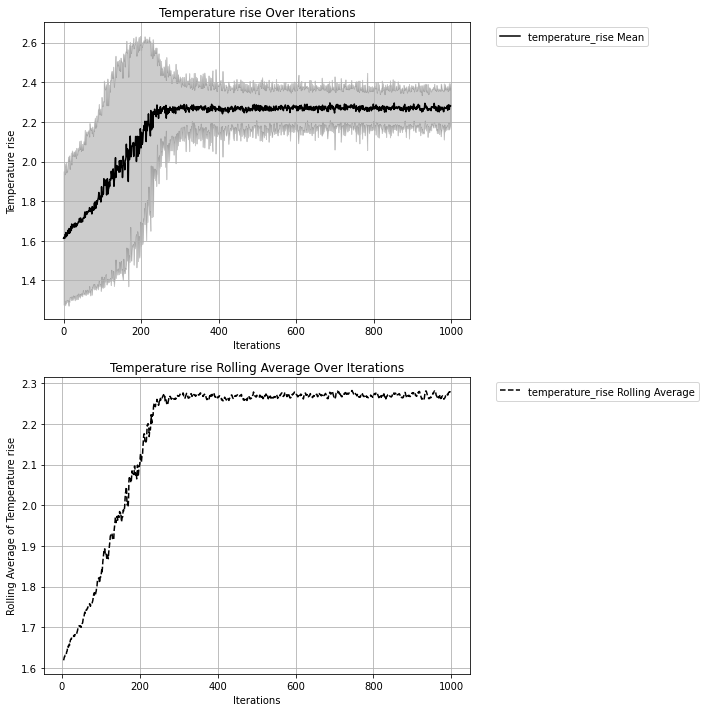

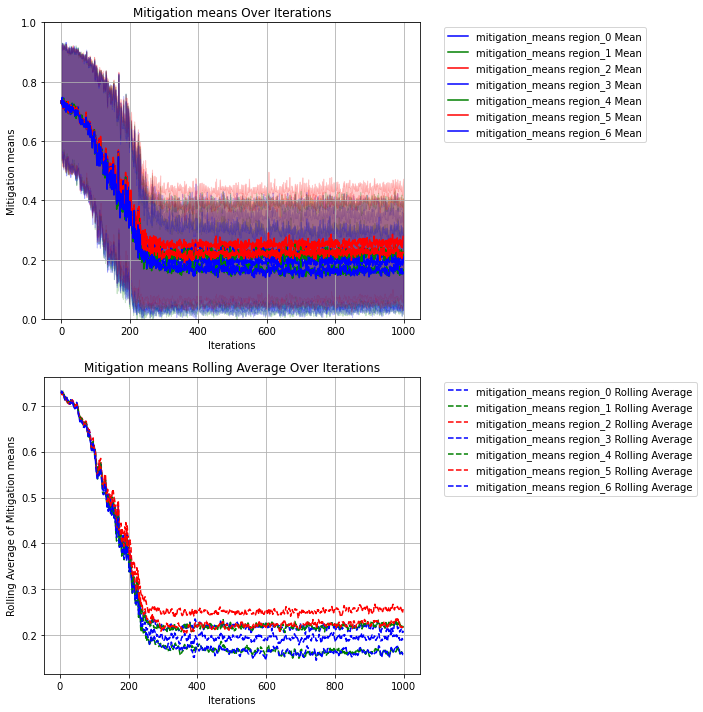

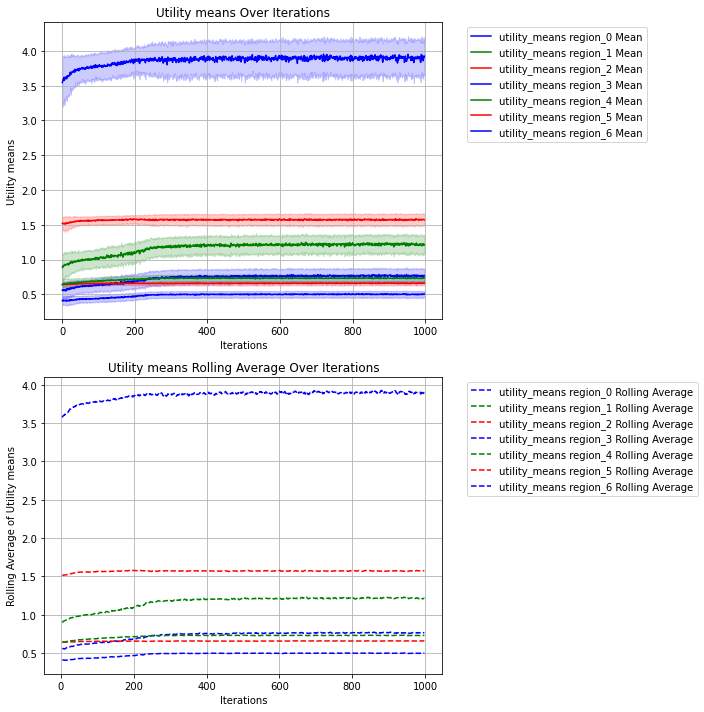

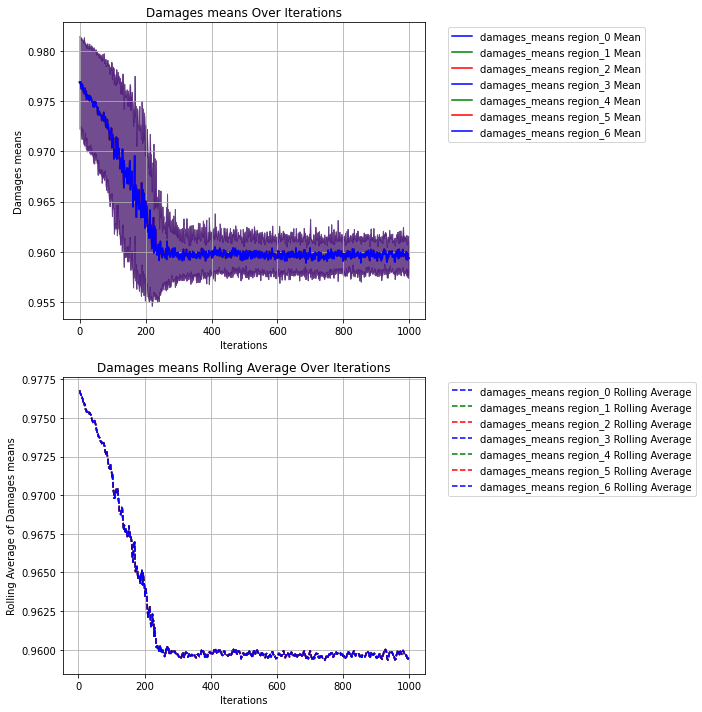

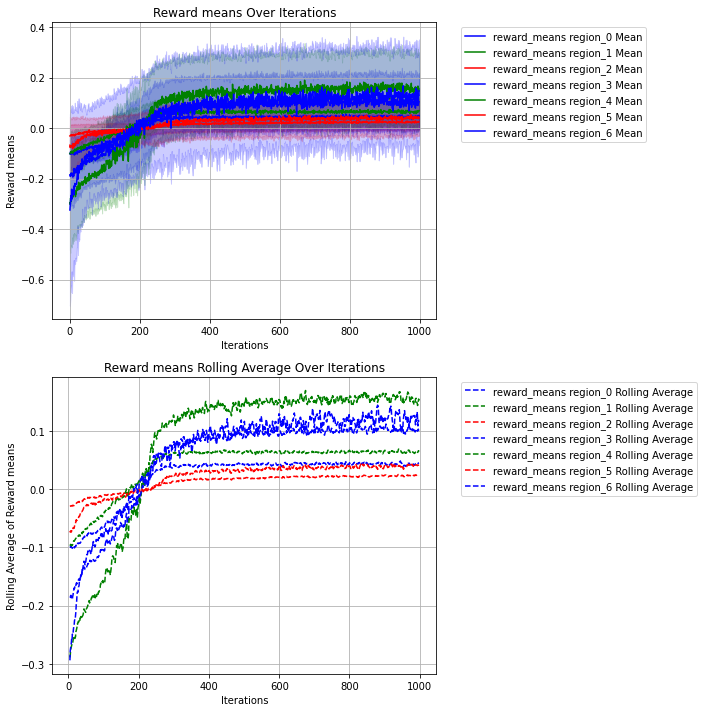

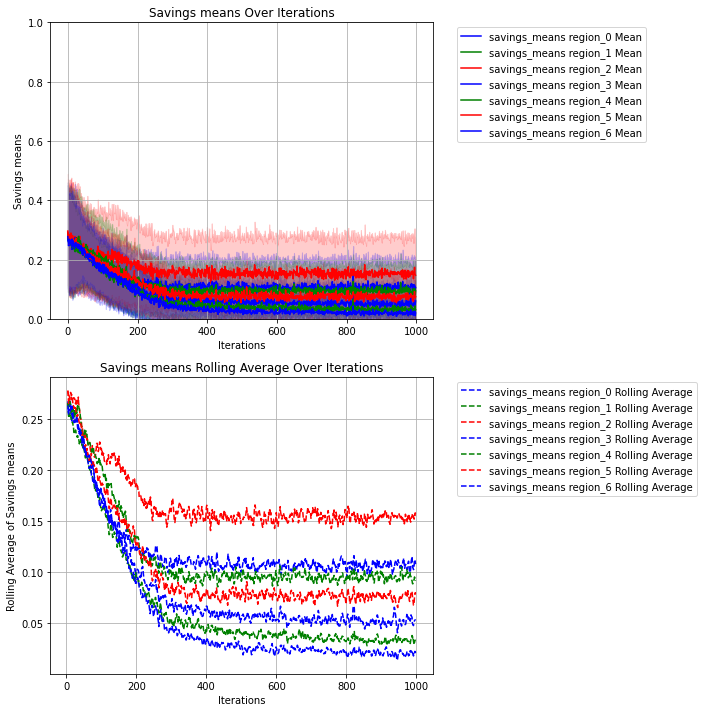

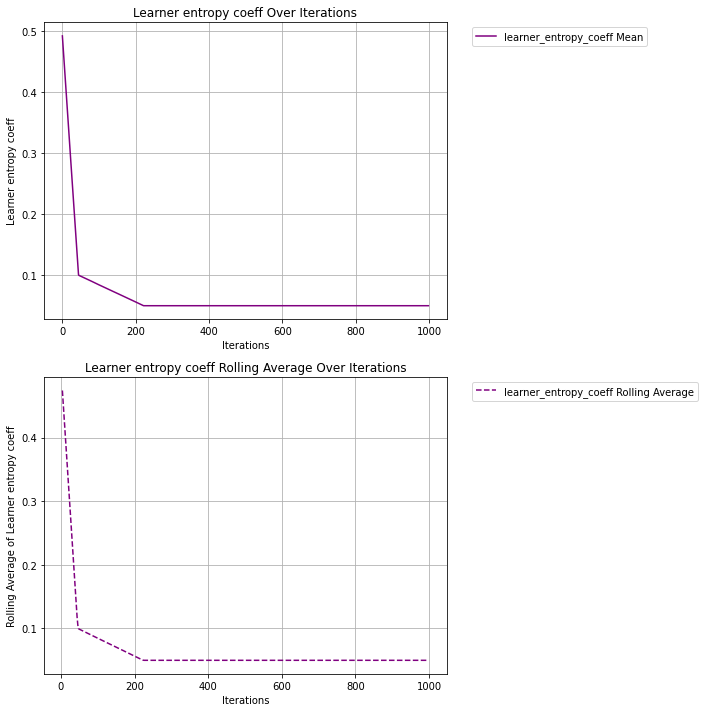

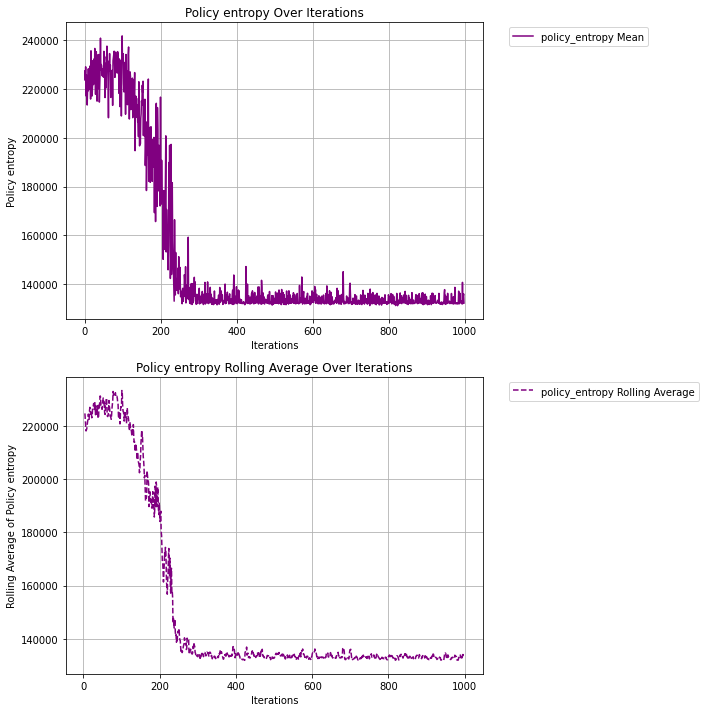

In [2]:
# import json
# import matplotlib.pyplot as plt

# # Load JSON data from a file
# file_path = '1738156115_BasicClubTariffAmbition_20.json'  # Replace with your JSON file path
# with open(file_path, 'r') as f:
#     data = json.load(f)

# data = [d for d in data if "mitigation_rates_all_regions_region_0" in d.keys()]
data= data_in
# Number of agents
num_agents = int(file_path.split("_")[2].replace(".json",""))

# Define metrics with mean, variance values
metrics = {
    "temperature_rise": {
        "mean": [d["temperature_rise_mean"] for d in data],
        "variance": [d["temperature_rise_variance"][0] for d in data]
    },
    "mitigation_means": {
        f'region_{i}': {
            "mean": [d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "utility_means": {
        f'region_{i}': {
            "mean": [d[f'utility_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'utility_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "damages_means": {
        f'region_{i}': {
            "mean": [d[f'damages_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'damages_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "reward_means": {
        f'region_{i}': {
            "mean": [d[f'reward_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'reward_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "savings_means": {
        f'region_{i}': {
            "mean": [d[f'savings_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'savings_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    # Add learner stats
    "learner_entropy_coeff": {
        "mean": [d["learner_stats"]["entropy_coeff"] for d in data]
    },
    "policy_entropy": {
        "mean": [d["learner_stats"]["policy_entropy"] for d in data]
    }
}

def plot_metric(metric_name, metric_data, window=5):
    plt.figure(figsize=(10, 10))  # Increase figure size for two plots
    colors = ['blue', 'green', 'red']  # Define a color palette for the regions

    # First subplot for original metrics
    plt.subplot(2, 1, 1)  # Create a 2x1 subplot grid, first subplot
    if metric_name not in ["temperature_rise", "learner_entropy_coeff", "policy_entropy"]:
        for idx, (region, values) in enumerate(metric_data.items()):
            mean_values = values["mean"]
            variance_values = values["variance"]
            std_dev = [v**0.5 for v in variance_values]
            
            color = colors[idx % len(colors)]  # Cycle through the color palette
            plt.plot(mean_values, label=f'{metric_name} {region} Mean', color=color)
            plt.fill_between(range(len(mean_values)), 
                             [m - s for m, s in zip(mean_values, std_dev)], 
                             [m + s for m, s in zip(mean_values, std_dev)], 
                             color=color, alpha=0.2)
    elif metric_name == "temperature_rise":
        mean_values = metric_data["mean"]
        variance_values = metric_data["variance"]
        std_dev = [v**0.5 for v in variance_values]
        
        plt.plot(mean_values, label=f'{metric_name} Mean', color='black')
        plt.fill_between(range(len(mean_values)), 
                         [m - s for m, s in zip(mean_values, std_dev)], 
                         [m + s for m, s in zip(mean_values, std_dev)], 
                         color='black', alpha=0.2)
        
    else:  # For learner stats that have only mean
        mean_values = metric_data["mean"]
        plt.plot(mean_values, label=f'{metric_name} Mean', color='purple')

    # Set y-axis range for specific metrics
    if metric_name in ["mitigation_means", "savings_means"]:
        plt.ylim(0, 1)  # Set y-axis range from 0 to 1

    plt.title(f'{metric_name.replace("_", " ").capitalize()} Over Iterations')
    plt.xlabel('Iterations')
    plt.ylabel(metric_name.replace("_", " ").capitalize())
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Second subplot for rolling averages
    plt.subplot(2, 1, 2)  # Second subplot
    if metric_name not in ["temperature_rise", "learner_entropy_coeff", "policy_entropy"]:
        for idx, (region, values) in enumerate(metric_data.items()):
            mean_values = values["mean"]
            rolling_avg = pd.Series(mean_values).rolling(window=window).mean()
            color = colors[idx % len(colors)]
            plt.plot(rolling_avg, label=f'{metric_name} {region} Rolling Average', color=color, linestyle='--')
    elif metric_name == "temperature_rise":
        mean_values = metric_data["mean"]
        rolling_avg = pd.Series(mean_values).rolling(window=window).mean()
        plt.plot(rolling_avg, label=f'{metric_name} Rolling Average', color='black', linestyle='--')
    else:  # For learner stats that have only mean
        mean_values = metric_data["mean"]
        rolling_avg = pd.Series(mean_values).rolling(window=window).mean()
        plt.plot(rolling_avg, label=f'{metric_name} Rolling Average', color='purple', linestyle='--')

    plt.title(f'{metric_name.replace("_", " ").capitalize()} Rolling Average Over Iterations')
    plt.xlabel('Iterations')
    plt.ylabel(f'Rolling Average of {metric_name.replace("_", " ").capitalize()}')
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Plot each metric
for metric_name, metric_data in metrics.items():
    plot_metric(metric_name, metric_data)


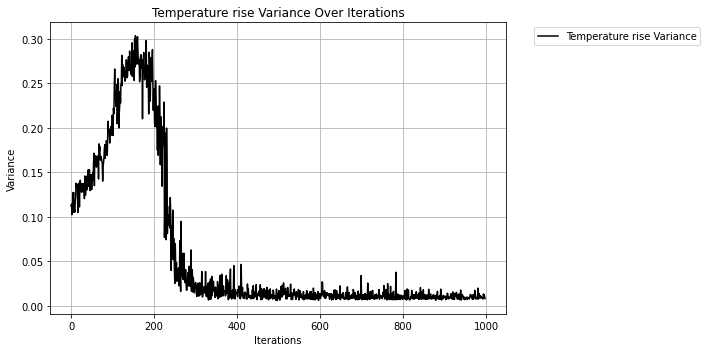

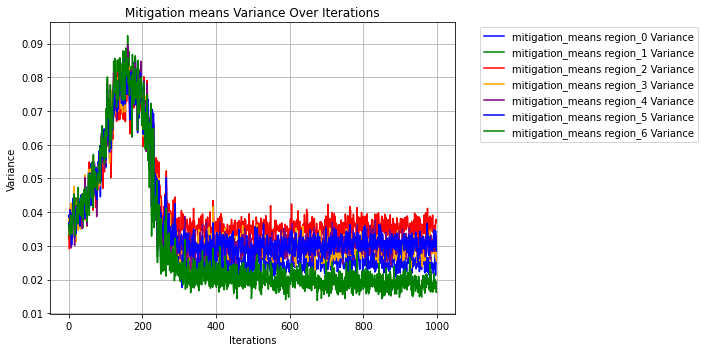

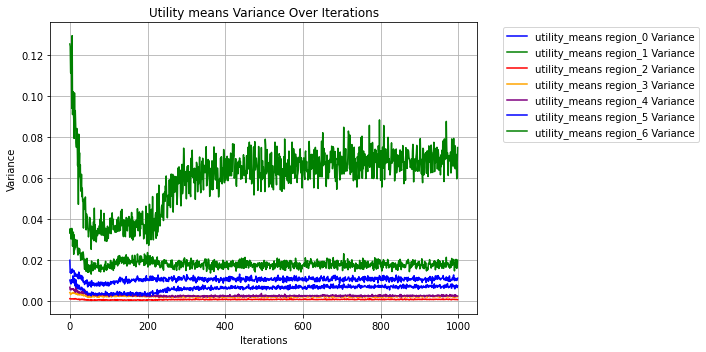

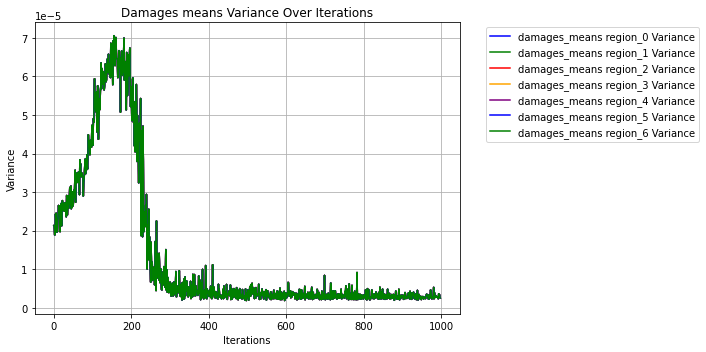

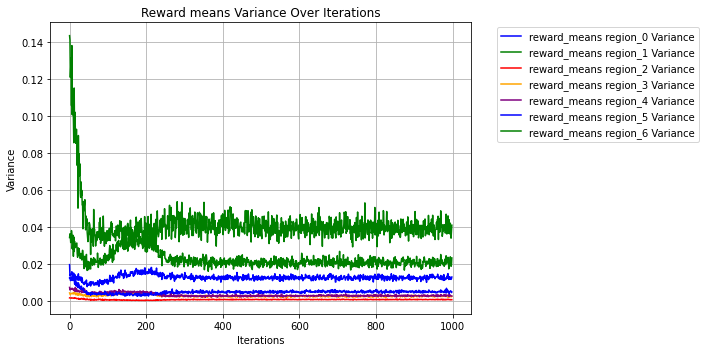

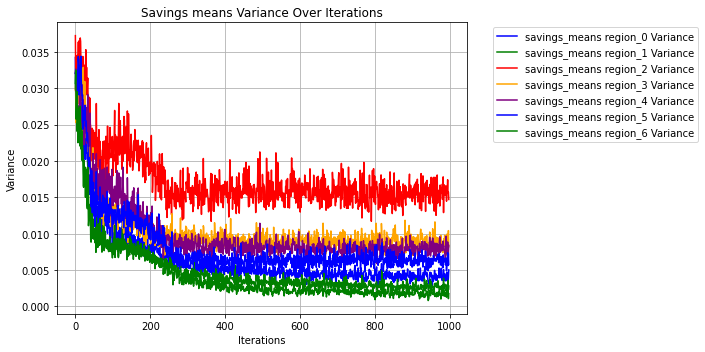

TypeError: list indices must be integers or slices, not str

<Figure size 720x360 with 0 Axes>

In [3]:
def plot_variance_for_all_metrics(metrics):
    for metric_name, metric_data in metrics.items():
        plt.figure(figsize=(10, 5))  # Set figure size
        colors = ['blue', 'green', 'red', 'orange', 'purple']  # Define a color palette for the regions
        
        # Plot variance for each metric
        if metric_name in ["temperature_rise"]:
            variance_values = metric_data["variance"]
            plt.plot(variance_values, label=f'{metric_name.replace("_", " ").capitalize()} Variance', color='black')
        
        else:  # For metrics with multiple regions
            for idx, (region, values) in enumerate(metric_data.items()):
                variance_values = values["variance"]
                color = colors[idx % len(colors)]  # Cycle through the color palette
                plt.plot(variance_values, label=f'{metric_name} {region} Variance', color=color)

        plt.title(f'{metric_name.replace("_", " ").capitalize()} Variance Over Iterations')
        plt.xlabel('Iterations')
        plt.ylabel('Variance')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# Plot variance for all metrics
plot_variance_for_all_metrics(metrics)

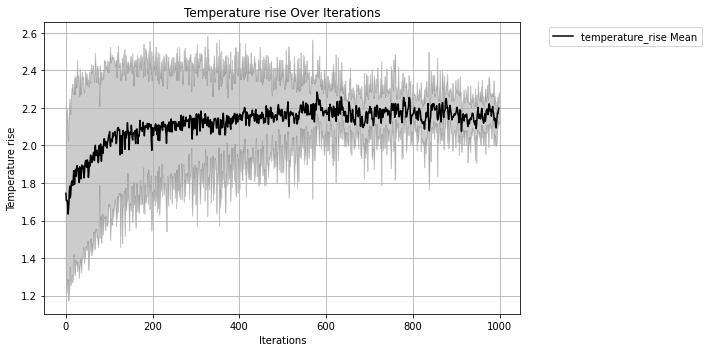

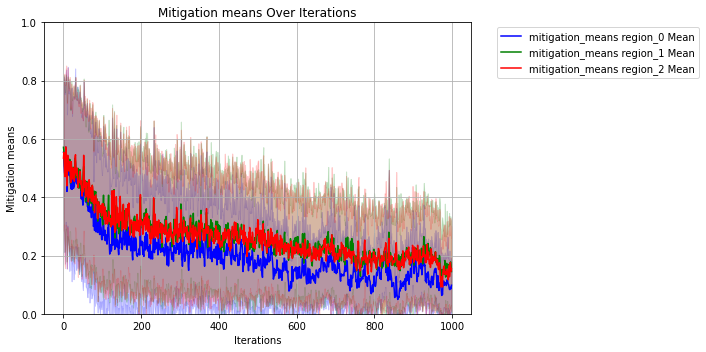

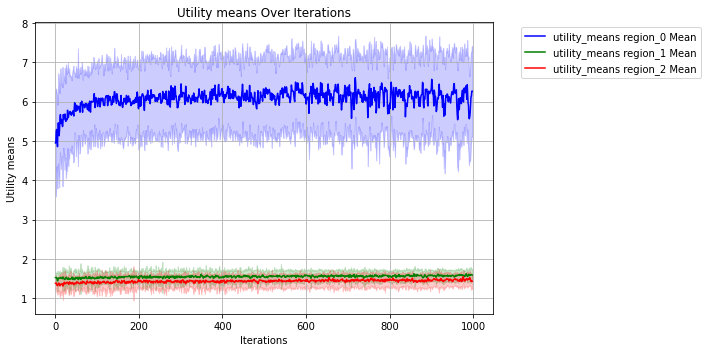

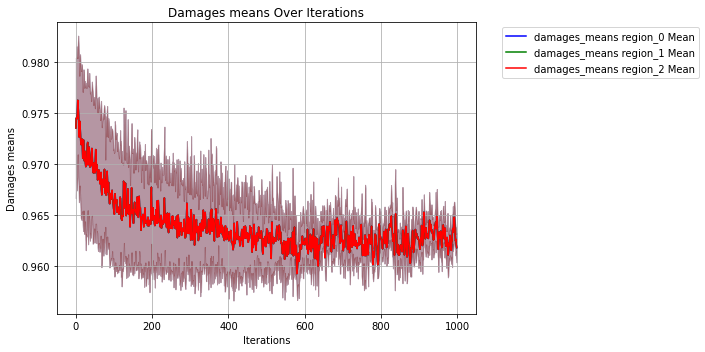

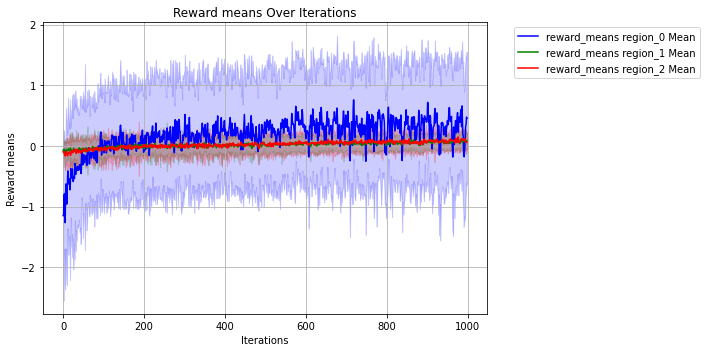

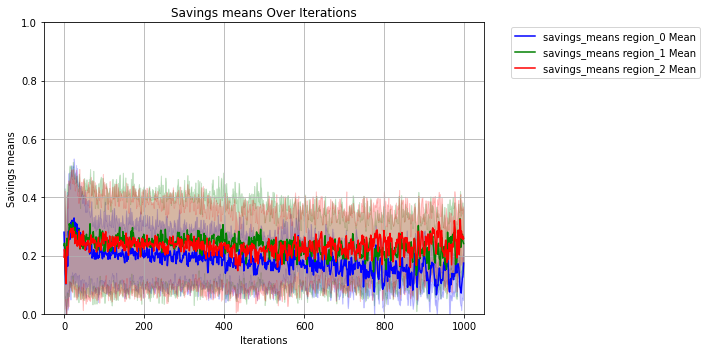

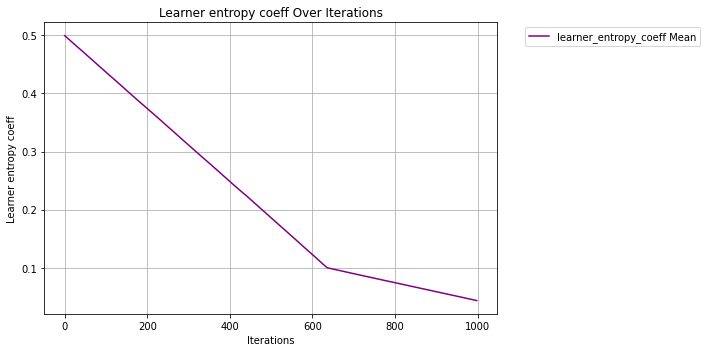

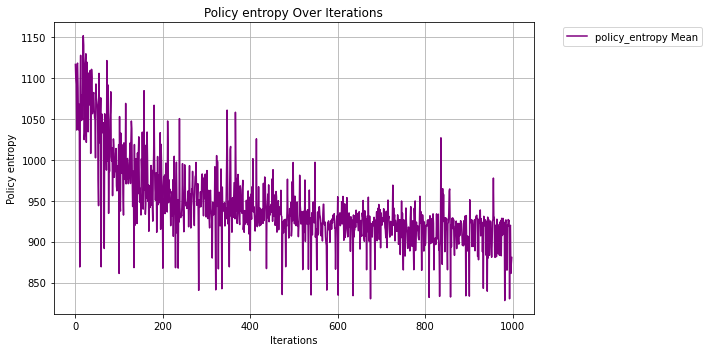

In [3]:
import json
import matplotlib.pyplot as plt

# Load JSON data from a file
file_path = '1738152570_BasicClubTariffAmbition_3.json'  # Replace with your JSON file path
with open(file_path, 'r') as f:
    data = json.load(f)

# data = [d for d in data if "mitigation_rates_all_regions_region_0" in d.keys()]

# Number of agents
num_agents = int(file_path.split("_")[2].replace(".json",""))

# Define metrics with mean, variance values
metrics = {
    "temperature_rise": {
        "mean": [d["temperature_rise_mean"] for d in data],
        "variance": [d["temperature_rise_variance"][0] for d in data]
    },
    "mitigation_means": {
        f'region_{i}': {
            "mean": [d[f'mitigation_rates_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'mitigation_rates_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "utility_means": {
        f'region_{i}': {
            "mean": [d[f'utility_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'utility_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "damages_means": {
        f'region_{i}': {
            "mean": [d[f'damages_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'damages_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "reward_means": {
        f'region_{i}': {
            "mean": [d[f'reward_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'reward_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    "savings_means": {
        f'region_{i}': {
            "mean": [d[f'savings_all_regions_region_{i}_mean'] for d in data],
            "variance": [d[f'savings_all_regions_region_{i}_variance'] for d in data]
        } for i in range(num_agents)
    },
    # Add learner stats
    "learner_entropy_coeff": {
        "mean": [d["learner_stats"]["entropy_coeff"] for d in data]
    },
    "policy_entropy": {
        "mean": [d["learner_stats"]["policy_entropy"] for d in data]
    }
}

def plot_metric(metric_name, metric_data):
    plt.figure(figsize=(10, 5))
    colors = ['blue', 'green', 'red']  # Define a color palette for the regions

    if metric_name not in ["temperature_rise", "learner_entropy_coeff", "policy_entropy"]:
        for idx, (region, values) in enumerate(metric_data.items()):
            mean_values = values["mean"]
            variance_values = values["variance"]
            std_dev = [v**0.5 for v in variance_values]
            
            color = colors[idx % len(colors)]  # Cycle through the color palette
            plt.plot(mean_values, label=f'{metric_name} {region} Mean', color=color)
            plt.fill_between(range(len(mean_values)), 
                             [m - s for m, s in zip(mean_values, std_dev)], 
                             [m + s for m, s in zip(mean_values, std_dev)], 
                             color=color, alpha=0.2)
    elif metric_name == "temperature_rise":
        mean_values = metric_data["mean"]
        variance_values = metric_data["variance"]
        std_dev = [v**0.5 for v in variance_values]
        
        plt.plot(mean_values, label=f'{metric_name} Mean', color='black')
        plt.fill_between(range(len(mean_values)), 
                         [m - s for m, s in zip(mean_values, std_dev)], 
                         [m + s for m, s in zip(mean_values, std_dev)], 
                         color='black', alpha=0.2)
        
    else:  # For learner stats that have only mean
        mean_values = metric_data["mean"]
        plt.plot(mean_values, label=f'{metric_name} Mean', color='purple')

    # Set y-axis range for specific metrics
    if metric_name in ["mitigation_means", "savings_means"]:
        plt.ylim(0, 1)  # Set y-axis range from 0 to 1

    plt.title(f'{metric_name.replace("_", " ").capitalize()} Over Iterations')
    plt.xlabel('Iterations')
    plt.ylabel(metric_name.replace("_", " ").capitalize())
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot each metric
for metric_name, metric_data in metrics.items():
    plot_metric(metric_name, metric_data)
